In [59]:
# Steel model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from scipy.optimize import OptimizeWarning
warnings.simplefilter('ignore', OptimizeWarning)

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (all_regions_list_class)

In [60]:
# Steel
steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                       image_mat_available = True, start_year = 1971, 
                       convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                       trade_data=True)



# steel_grouping = {'all': all_regions_list_class[:-1]}

high = ['class_ 14', 'class_ 19', 'class_ 20']
low = ['class_ 3', 'class_ 4', 'class_ 5', 'class_ 6', 
       'class_ 7', 'class_ 8', 'class_ 9', 'class_ 10', 
       'class_ 11', 'class_ 17', 'class_ 18', 'class_ 21', 
       'class_ 22', 'class_ 24', 'class_ 25', 'class_ 26']
       
rest = all_regions_list_class[:-1]
rest = [r for r in rest if r not in (high+low)]


steel_grouping = {'all' : all_regions_list_class[:-1]}


steel.data_grouped_regions(regions_grouping = steel_grouping)

# get drivers for fitting (regions dont need to be summed, regions dict is none)
steel.sum_IMAGE_drivers_regions(regions_dict=None)

steel.match_MAT_data_to_regions_year(match_external_regions=False)
steel.calculate_historic_other_fraction()

In [61]:
# Share of IAMGE MAT data to total consumption
share_mat_total = (steel.image_mat_data/steel.historic_consumption_data*100).mean()

In [62]:
# deal with regions where there are negative values because consumption was lower than mat projections
steel.historic_other_fraction_consumption[['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']]

# too many negative: class 4, 8, 9, 22, 25, 26
# assumption: IMAGE MATERIALS is overestimating, 
# real consumption numbers are true &  
# TODO: MATERIALS calculations should be scaled down accordingly 
neg_classes = ['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']
steel.historic_other_fraction_consumption[neg_classes] = steel.historic_consumption_data[neg_classes]

# deal with single negative numbers by removing them from dataset
steel.historic_other_fraction_consumption[steel.historic_other_fraction_consumption < 0] = np.nan


<Axes: >

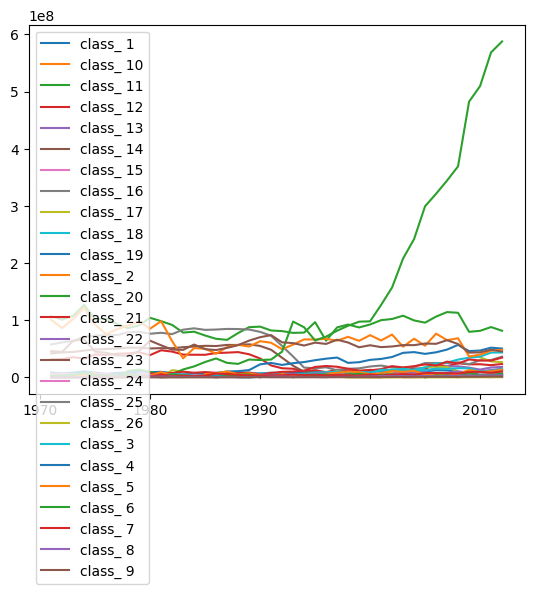

In [63]:
# Plot
steel.historic_other_fraction_consumption.plot()

In [64]:

# Fit models 
steel.calculate_regressors(steel.historic_other_fraction_consumption)
steel.fit_models(best_rmse_models=None)

# Best models
steel.best_rmse_models
steel.merged_rmse_r2

# project based on best model
steel.project_on_total(all_regions_list_class[:-1])

all


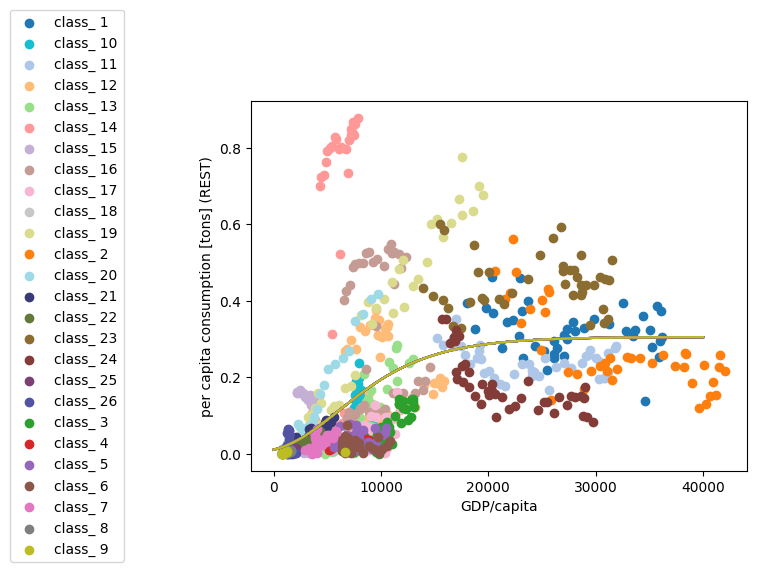

In [65]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', '#637939', '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in steel.cons_capita.columns:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
    
    ax.plot(steel.region_model_match.get(region).predict(np.arange(1, 40001).reshape(-1, 1)),
            color = color_dict.get(region))

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")



ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))

In [66]:
# neg_classes = ['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']
# are fitted for total steel conumption not for the rest of, so ignoring IMAGE Mat data, therefore, IMAGE Mat does not need to be added to these regions in total projection data
#  

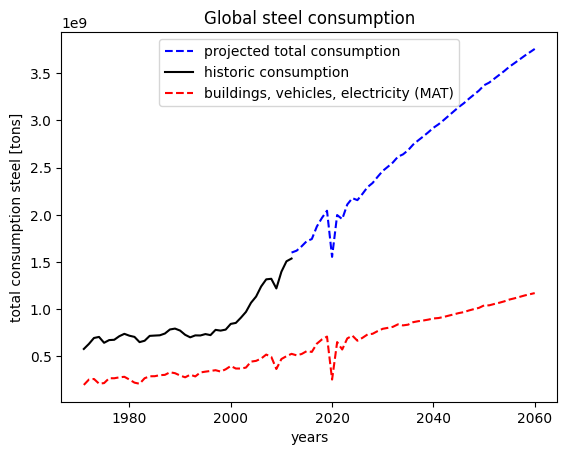

In [67]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(steel.projection_per_region_total.sum(axis = 1) + steel.image_mat_data.sum(axis = 1).loc[2012:], 
        linestyle = '--', color = 'blue', label = 'projected total consumption')
ax.plot(steel.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(steel.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.set_ylabel("total consumption steel [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global steel consumption")
ax.legend(loc = 'upper center')

In [68]:
def plot_total_consumption_per_region(region):

        fig, ax = plt.subplots()             # Create a figure containing a single Axes.


        if region in neg_classes:
            print(f"Region {region} has a higher consumption in MAT than the total, so using unly historic consumption data instead of projection.")
            ax.plot((steel.projection_per_region[region]*steel.pop_100[region]), 
                    linestyle = '-', color = 'black', label = 'projected total consumption')
        else:
               ax.plot((steel.projection_per_region[region]*steel.pop_100[region]) + steel.image_mat_data[region].loc[2012:],
                       linestyle = '--', color = 'blue', label = 'projected total consumption')
        ax.plot(steel.historic_consumption_data[region],
                linestyle = '-', color = 'black', label = 'historic consumption')  

        ax.plot(steel.image_mat_data[region].loc[1971:],
                linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

        ax.set_ylabel("total consumption steel [tons]")
        ax.set_xlabel("years") 
        ax.title.set_text("Global steel consumption")
        ax.legend(loc = 'upper center')

In [69]:
# try to get gompertz parameters for all regions

steel.region_model_match.get('class_ 1')._coefs

array([0.30567183, 3.35772799, 0.20037505])

[0.30567183 3.35772799 0.20037505]


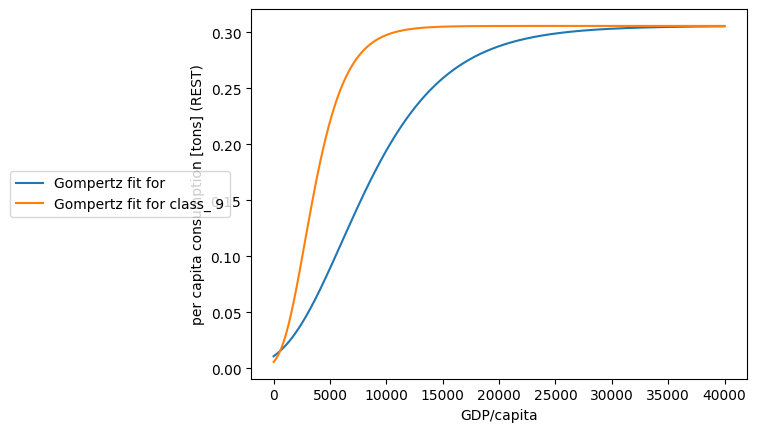

In [86]:
# Plot diffferent regions with Gompertz fit
X_axis = np.arange(1, 40001).reshape(-1, 1) # GDP/capita input for Gompertz fit
X_input = np.arange(1, 40001).reshape(-1, 1)/1000  # GDP/capita input for Gompertz fit

coefs_standard = steel.region_model_match.get(region)._coefs
print(coefs_standard)


fig, ax = plt.subplots()             # Create a figure containing a single Axes.

 
# Gompertz fit
y_1 = (coefs_standard[0] * np.exp(-coefs_standard[1] * np.exp(-coefs_standard[2] * X_input)))
y_2 = (coefs_standard[0] * np.exp(-4 * np.exp(-0.5 * X_input)))
    
ax.plot(X_axis, y_1, label=f'Gompertz fit for')
ax.plot(X_axis, y_2, label=f'Gompertz fit for {region}')

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")



ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))